In [2]:
import sys
print(sys.executable)

C:\Users\LENOVO\anaconda3\python.exe


In [3]:
%pip install mysql-connector-python

   ---------------------------------------- 0.0/480.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/480.6 kB ? eta -:--:--
    --------------------------------------- 10.2/480.6 kB ? eta -:--:--
    --------------------------------------- 10.2/480.6 kB ? eta -:--:--
    --------------------------------------- 10.2/480.6 kB ? eta -:--:--
   --- ----------------------------------- 41.0/480.6 kB 281.8 kB/s eta 0:00:02
   --- ----------------------------------- 41.0/480.6 kB 281.8 kB/s eta 0:00:02
   -------- ----------------------------- 112.6/480.6 kB 504.4 kB/s eta 0:00:01
   -------- ----------------------------- 112.6/480.6 kB 504.4 kB/s eta 0:00:01
   ------------------ ------------------- 235.5/480.6 kB 722.1 kB/s eta 0:00:01
   ------------------ ------------------- 235.5/480.6 kB 722.1 kB/s eta 0:00:01
   ---------------------------------------  471.0/480.6 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 480.6/480.6 kB 1.0 MB/s eta 0:00:00
No

In [1]:
import mysql.connector

In [2]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Dhanush",
    database="sales_db"
)

print("Connected Successfully!")

Connected Successfully!


In [4]:
query = "SELECT * FROM sales"

df = pd.read_sql(query, conn)

df

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3736\1415883195.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,product,quantity,price
0,1,Laptop,2,60000.0
1,2,Mouse,5,500.0
2,3,Keyboard,3,1200.0
3,4,Laptop,1,60000.0
4,5,Mouse,7,500.0
5,6,Keyboard,2,1200.0
6,7,Monitor,4,15000.0
7,8,Monitor,1,15000.0


In [5]:
query = """
SELECT
    product,
    SUM(quantity) AS Total_Quantity,
    SUM(quantity * price) AS Revenue
FROM sales
GROUP BY product;
"""

sales_summary = pd.read_sql(query, conn)

sales_summary

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3736\3267992217.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_summary = pd.read_sql(query, conn)


,product,Total_Quantity,Revenue
0,Laptop,3.0,180000.0
1,Mouse,12.0,6000.0
2,Keyboard,5.0,6000.0
3,Monitor,5.0,75000.0


In [6]:
query = """
SELECT
    SUM(quantity) AS Total_Items_Sold,
    SUM(quantity * price) AS Total_Revenue
FROM sales;
"""

overall_summary = pd.read_sql(query, conn)

overall_summary

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3736\1368141490.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  overall_summary = pd.read_sql(query, conn)


,Total_Items_Sold,Total_Revenue
0,25.0,267000.0


In [7]:
print("Sales Summary")
print(sales_summary)

print("\nOverall Sales Summary")
print(overall_summary)

Sales Summary
    product  Total_Quantity   Revenue
0    Laptop             3.0  180000.0
1     Mouse            12.0    6000.0
2  Keyboard             5.0    6000.0
3   Monitor             5.0   75000.0

Overall Sales Summary
   Total_Items_Sold  Total_Revenue
0              25.0       267000.0


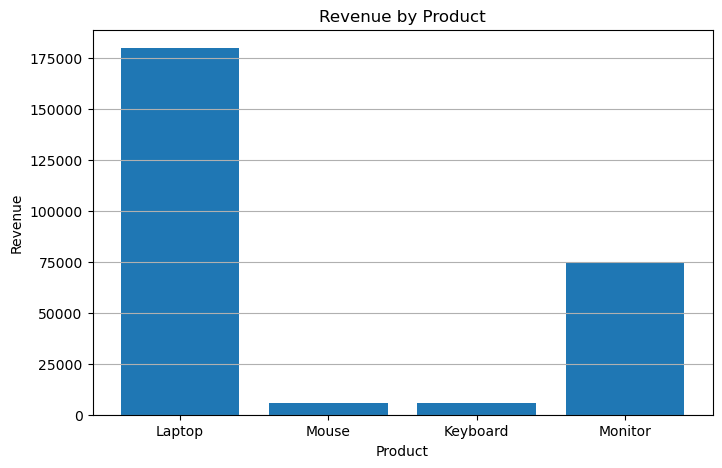

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_summary["product"],
    sales_summary["Revenue"]
)

plt.title("Revenue by Product")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.grid(axis='y')

plt.show()

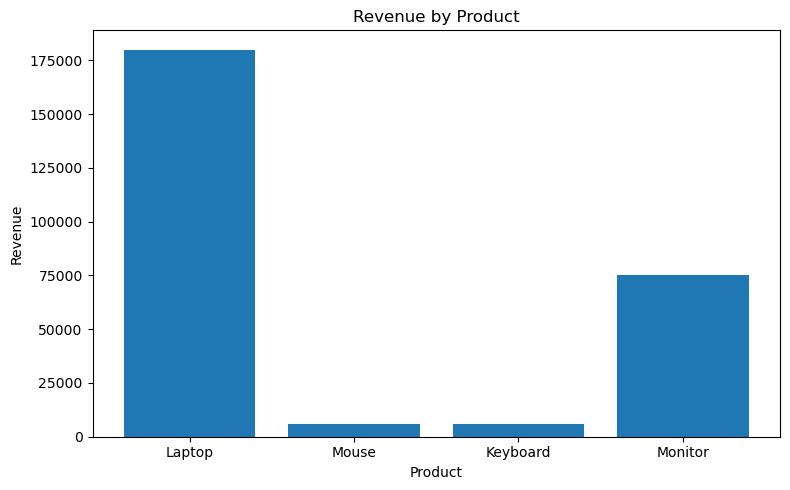

In [22]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_summary["product"],
    sales_summary["Revenue"]
)

plt.title("Revenue by Product")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    r"C:\Users\LENOVO\Downloads\Sales_Project\charts\Revenue_by_Product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
query = """
SELECT
product,
SUM(quantity*price) AS Revenue
FROM sales
GROUP BY product
ORDER BY Revenue DESC
LIMIT 1;
"""

highest = pd.read_sql(query, conn)

print(highest)

  product   Revenue
0  Laptop  180000.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3736\2314940762.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  highest = pd.read_sql(query, conn)


In [11]:
query = """
SELECT
product,
SUM(quantity) AS Quantity
FROM sales
GROUP BY product
ORDER BY Quantity DESC
LIMIT 1;
"""

highest_qty = pd.read_sql(query, conn)

print(highest_qty)

  product  Quantity
0   Mouse      12.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3736\2974785598.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  highest_qty = pd.read_sql(query, conn)


In [12]:
query = """
SELECT
product,
AVG(price) AS Average_Price
FROM sales
GROUP BY product;
"""

avg_price = pd.read_sql(query, conn)

print(avg_price)

    product  Average_Price
0    Laptop        60000.0
1     Mouse          500.0
2  Keyboard         1200.0
3   Monitor        15000.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3736\698404328.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  avg_price = pd.read_sql(query, conn)


In [13]:
query = """
SELECT
product,
COUNT(*) AS Number_of_Sales
FROM sales
GROUP BY product;
"""

sales_count = pd.read_sql(query, conn)

print(sales_count)

    product  Number_of_Sales
0    Laptop                2
1     Mouse                2
2  Keyboard                2
3   Monitor                2


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3736\1471481538.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_count = pd.read_sql(query, conn)


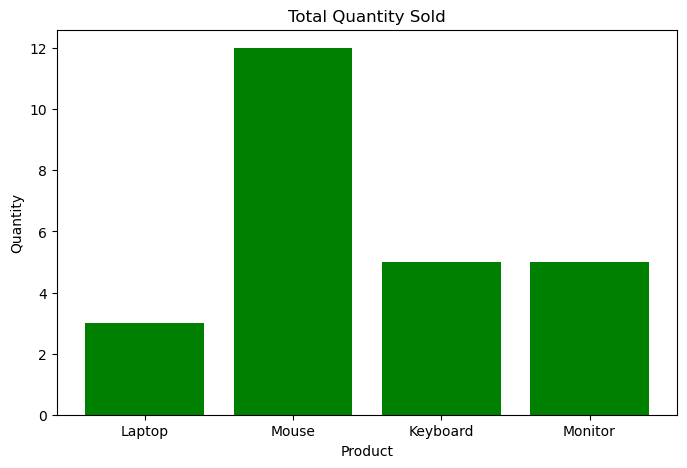

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    sales_summary["product"],
    sales_summary["Total_Quantity"],
    color="green"
)

plt.title("Total Quantity Sold")

plt.xlabel("Product")

plt.ylabel("Quantity")

plt.savefig(
    r"C:\Users\LENOVO\Downloads\Sales_Project\charts\Total_Quantity_Sold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

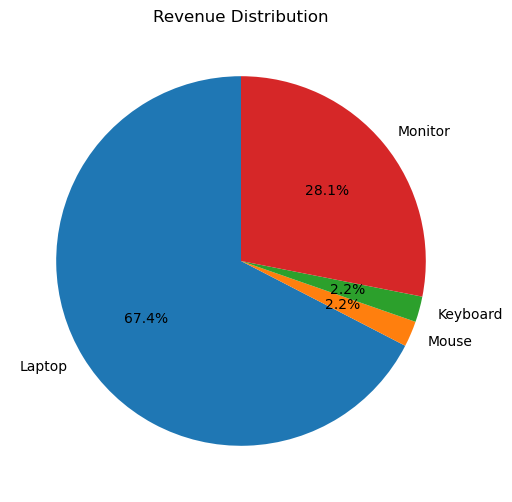

In [24]:
plt.figure(figsize=(6,6))

plt.pie(
    sales_summary["Revenue"],
    labels=sales_summary["product"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Distribution")
plt.savefig(
    r"C:\Users\LENOVO\Downloads\Sales_Project\charts\Revenue_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

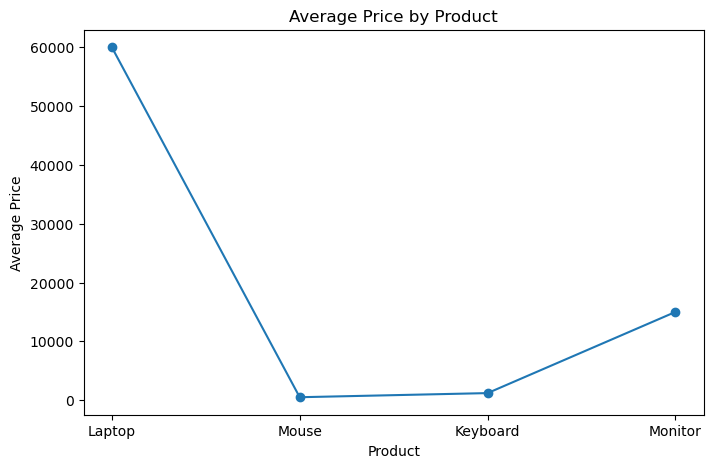

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    avg_price["product"],
    avg_price["Average_Price"],
    marker="o"
)

plt.title("Average Price by Product")

plt.xlabel("Product")

plt.ylabel("Average Price")

plt.savefig(
    r"C:\Users\LENOVO\Downloads\Sales_Project\charts\Average_Price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
query = """
SELECT
product,
SUM(quantity*price) AS Revenue
FROM sales
GROUP BY product
ORDER BY Revenue DESC;
"""

ranking = pd.read_sql(query, conn)

print(ranking)

    product   Revenue
0    Laptop  180000.0
1   Monitor   75000.0
2     Mouse    6000.0
3  Keyboard    6000.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3736\2150777145.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ranking = pd.read_sql(query, conn)


In [21]:
import os

save_path = r"C:\Users\LENOVO\Downloads\Sales_Project\charts"

os.makedirs(save_path, exist_ok=True)

print("Folder Ready!")

Folder Ready!
